# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 10</span>

### Exercise 10.1

Choose **ONLY ONE** of the two following possibilities:

1. Parallelize with MPI libraries your Genetic Algorithm code in order to solve the TSP by performing a *Genetic Search* with (up to) 11 **parallel GA searches of the optimal path**:
each node should perform an independent GA search, the so-called *Continent*, **but** every $N_{migr}$ generations the *Continents* should exchange their best individuals randomly.

2. Starting from your Genetic Algorithm code implement a **Parallel Tempering algorithm** (Simulated Annealing with many temperatures). Parallelize with MPI libraries your algorithm in order to solve the TSP where each computing node, up to 11, is characterized by a different temperature or a limited set of temperatures (if you need more than 11 temperatures). Use your genetic operators (except crossover) as trial moves for the Metropolis algorithm and **add a trial move that proposes an exchange of paths among adjacent temperatures (nodes)** (see lecture 8 for the acceptance formula). The candidate solution of the TSP will appear on the node with the lowest temperature.

### Exercise 10.2

Apply your parallel code to the TSP problem for 110 italian "capoluoghi di provincia" longitude and latitude coordinates in the *cap_prov_ita.dat* file.

If your choice in Exercise 10.1 is option 1, do you improve with respect using the same number of computing cores but with **independent GA searches** ?

If your choice in Exercise 10.1 is option 2, by using a number of temperatures equal to the number of individuals in your **non-parallel Genetic Algorithm code**, do you "improve" with respect to it?

### Parametri del mio algoritmo genetico

- numero città $= 110$
- $p = 2$
- numero individui in una popolazione $= 150$
- numero di migrazioni $= 400$
- parametro_1 $=$ un intero random tra $2$ e $15$
- parametro_2 $=$ un intero random tra $1$ e $($numero città / $2) - 1$ 
- parametro_5 $=$ un intero random tra $2$ e numero città / $4$
- probabilita pair_permutation $= 0.05$
- probabilita block_permutation $= 0.05$ con lunghezza del blocco $=$ parametro_1 e lughezza spostamento $=$ parametro_2
- probabilita block_shift $= 0.0$ 
- probabilita block_inversion $= 0.25$ con lunghezza del blocco $=$ parametro_5
- probabilita crossover $= 0.6$
- numero iterazioni $=1000$

In [5]:
import matplotlib.pyplot as plt
import numpy as np

data_italia = np.loadtxt('../Lab9/cap_prov_ita.dat')
data_configurazione = np.loadtxt('configurazione_finale_true.dat')


x = data_italia[:,0]
y = data_italia[:,1]
x_percorso = data_configurazione[:,0]
y_percorso = data_configurazione[:,1]


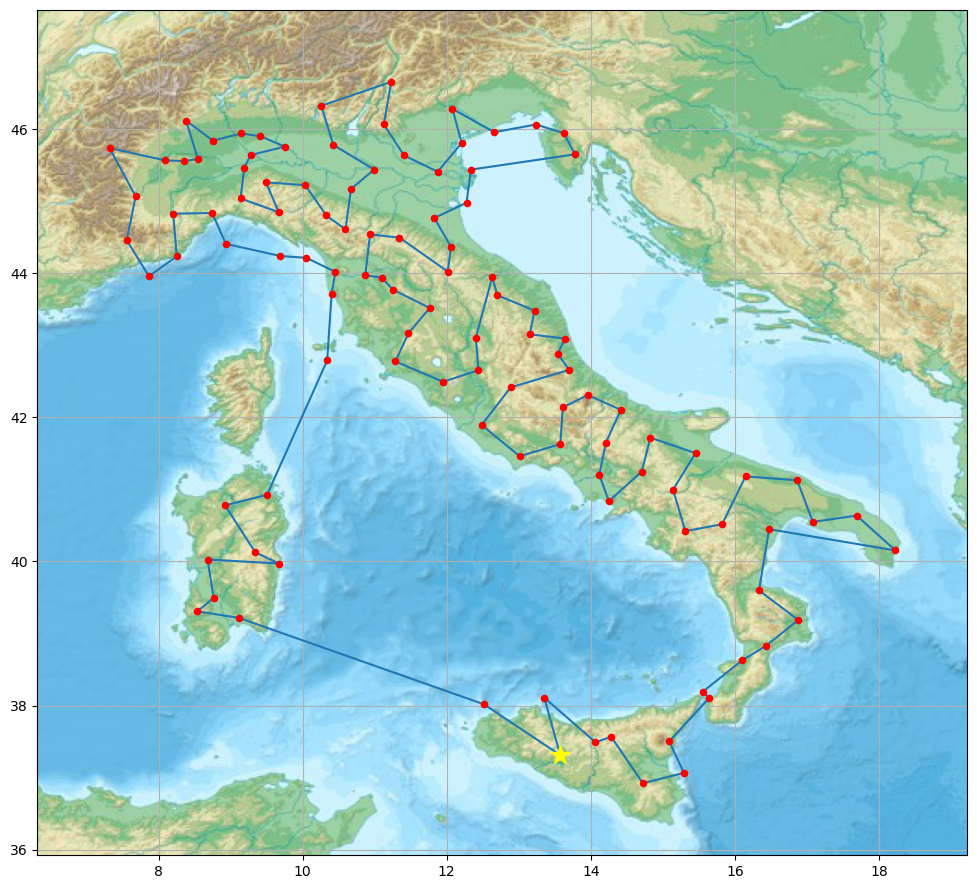

In [6]:
img = plt.imread("../Lab9/italia.jpeg")
plt.figure(figsize=(12, 12))

# 'extent' definisce l'area coperta dall'immagine [xmin, xmax, ymin, ymax]
plt.imshow(img, extent=[x.min()-1, x.max()+1, y.min()-1, y.max()+1], aspect='auto')

plt.plot(x_percorso, y_percorso, zorder=2, label="Percorso")
plt.scatter(x, y, c='r', s=20, zorder=3)
plt.scatter(x_percorso[0], y_percorso[0], marker="*", s=200, color="yellow", zorder=5)
plt.grid(True)
plt.gca().set_aspect('equal')
plt.show()

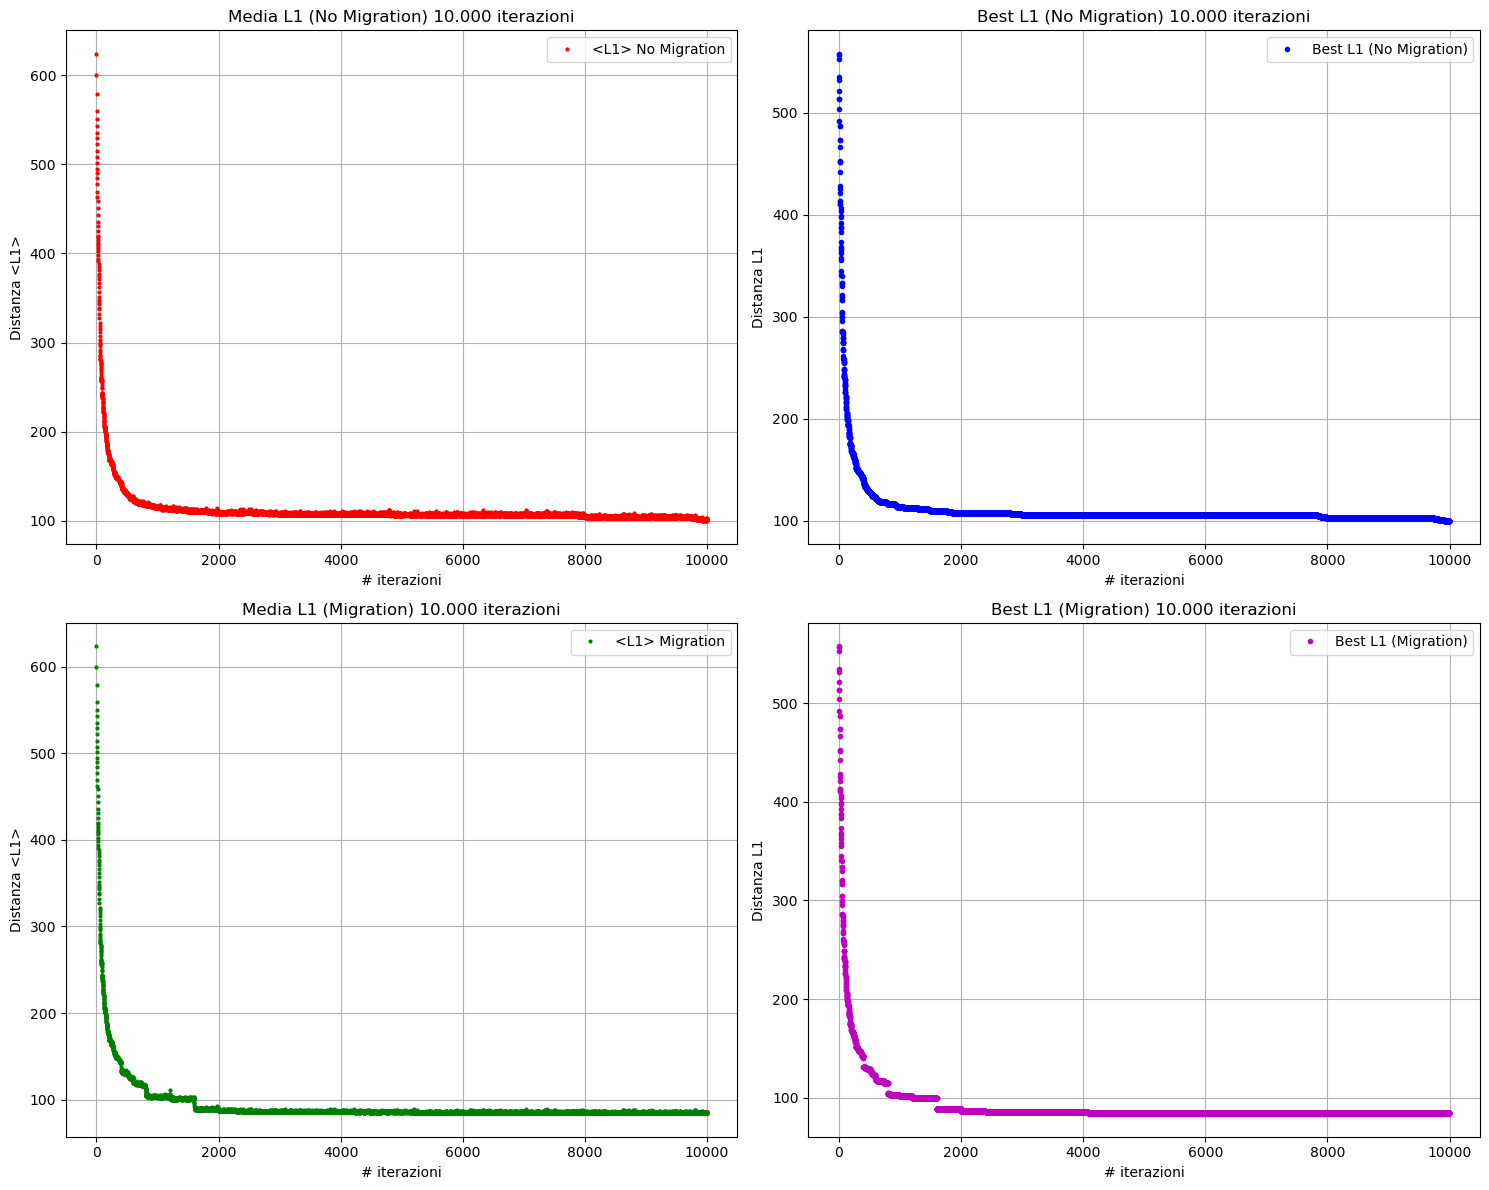

In [10]:
import matplotlib.pyplot as plt
import numpy as np

L1_false = np.loadtxt('Dati_L1(iterazioni)_false')
L1_best_false = np.loadtxt('Dati_best(iterazioni)_false')
L1_true = np.loadtxt('Dati_L1(iterazioni)_true')
L1_best_true = np.loadtxt('Dati_best(iterazioni)_true')

fig, axs = plt.subplots(2, 2, figsize=(15, 12))

axs[0, 0].plot(np.arange(len(L1_false)), L1_false, 'ro', markersize=2, label="<L1> No Migration")
axs[0, 0].set_title("Media L1 (No Migration) 10.000 iterazioni")
axs[0, 0].set_xlabel("# iterazioni")
axs[0, 0].set_ylabel("Distanza <L1>")
axs[0, 0].grid(True)
axs[0, 0].legend()

axs[0, 1].plot(np.arange(len(L1_best_false)), L1_best_false, 'bo', markersize=3, label="Best L1 (No Migration)")
axs[0, 1].set_title("Best L1 (No Migration) 10.000 iterazioni")
axs[0, 1].set_xlabel("# iterazioni")
axs[0, 1].set_ylabel("Distanza L1")
axs[0, 1].grid(True)
axs[0, 1].legend()

axs[1, 0].plot(np.arange(len(L1_true)), L1_true, 'go', markersize=2, label="<L1> Migration")
axs[1, 0].set_title("Media L1 (Migration) 10.000 iterazioni")
axs[1, 0].set_xlabel("# iterazioni")
axs[1, 0].set_ylabel("Distanza <L1>")
axs[1, 0].grid(True)
axs[1, 0].legend()

axs[1, 1].plot(np.arange(len(L1_best_true)), L1_best_true, 'mo', markersize=3, label="Best L1 (Migration)")
axs[1, 1].set_title("Best L1 (Migration) 10.000 iterazioni")
axs[1, 1].set_xlabel("# iterazioni")
axs[1, 1].set_ylabel("Distanza L1")
axs[1, 1].grid(True)
axs[1, 1].legend()

plt.tight_layout()
plt.savefig('confronto_parallelo.png', dpi=300)
plt.show()

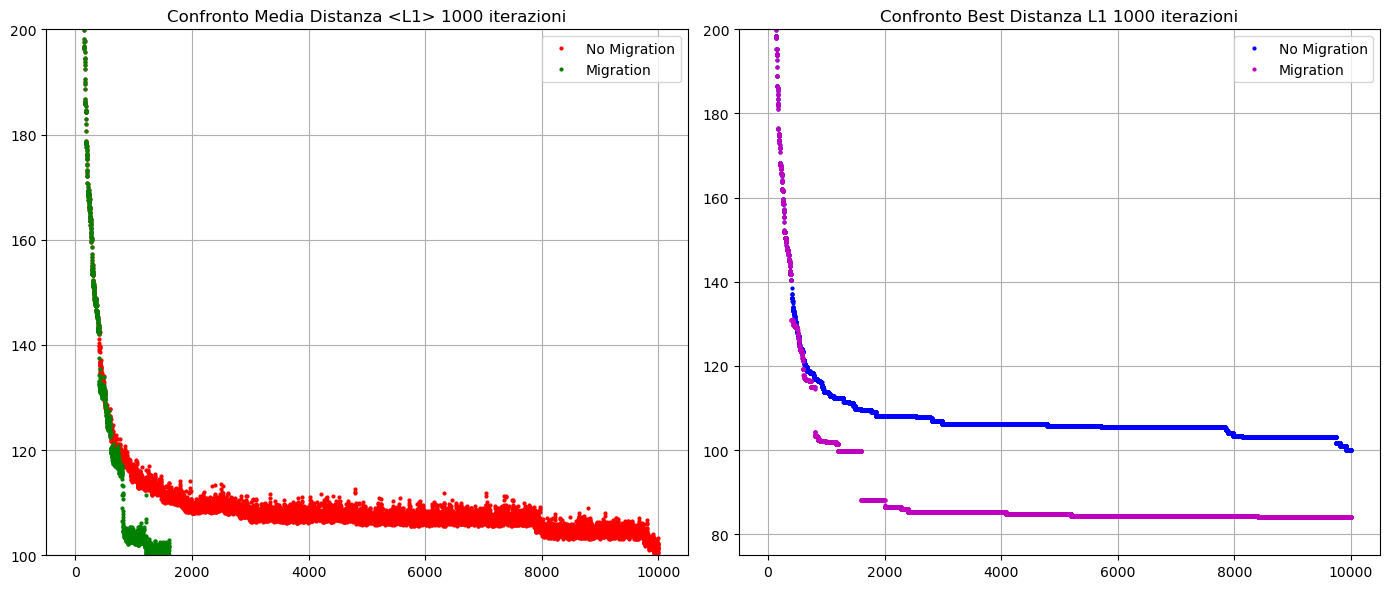

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.plot(L1_false, 'ro', markersize=2, label="No Migration")
ax1.plot(L1_true, 'go', markersize=2, label="Migration")
ax1.set_title("Confronto Media Distanza <L1> 1000 iterazioni")
ax1.set_ylim(100, 200)
ax1.grid(True)
ax1.legend()

ax2.plot(L1_best_false, 'bo', markersize=2, label="No Migration")
ax2.plot(L1_best_true, 'mo', markersize=2, label="Migration")
ax2.set_title("Confronto Best Distanza L1 1000 iterazioni")
ax2.set_ylim(75, 200)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

Come è possibile notare dai grafici soprastanti, le migrazioni restituiscono risultati decisamente migliori.

Nel grafico della Media Distanza $\langle L_1 \rangle$ si nota come la configurazione con Migration (in verde) crolli verso valori di distanza ottimi in meno di 1000 iterazioni, stabilizzandosi rapidamente. Al contrario, la curva senza iterazioni (in rosso) richiede tutte le 10.000 iterazioni per avvicinarsi a quel livello di ottimizzazione, mostrando continue fluttuazioni e una discesa estremamente più lenta.

L'algoritmo caratterizzato dalle migrazioni (in viola) esegue dei "salti" oltre certe regioni nei primi 2000 passi, segno che l'introduzione di geni esterni (immigrati da altri nodi paralleli) ha sbloccato la popolazione da minimi locali in cui era intrappolata. L'algoritmo senza migrazioni (in blu) invece, rimane invece bloccato in una zona circa piatta per migliaia di generazioni, findendo con distanza molto superiore.

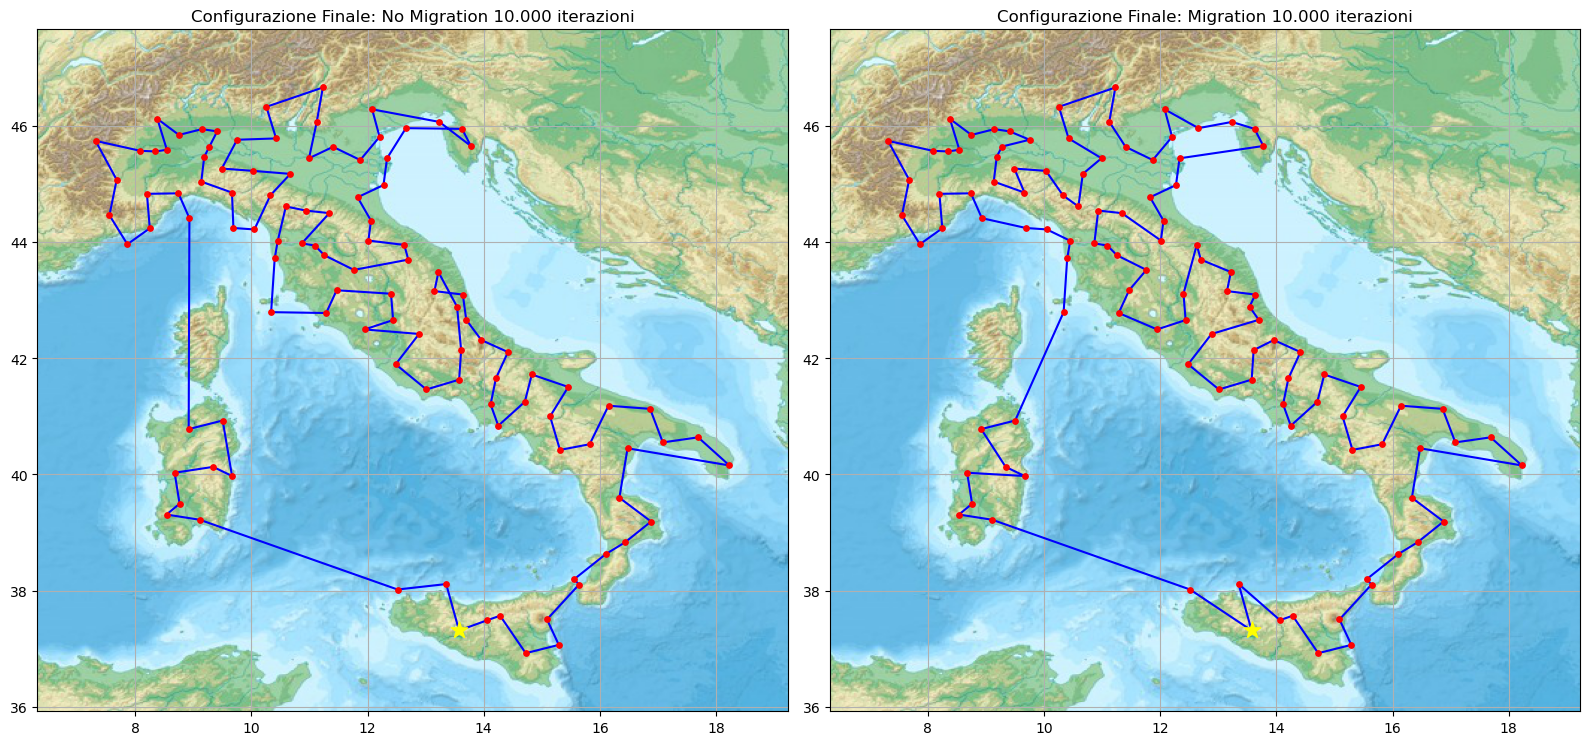

In [11]:
import matplotlib.pyplot as plt
import numpy as np

data_italia = np.loadtxt('../Lab9/cap_prov_ita.dat')
data_config_true = np.loadtxt('configurazione_finale_true.dat')
data_config_false = np.loadtxt('configurazione_finale_false')

x, y = data_italia[:, 0], data_italia[:, 1]
x_true, y_true = data_config_true[:, 0], data_config_true[:, 1]
x_false, y_false = data_config_false[:, 0], data_config_false[:, 1]

img = plt.imread("../Lab9/italia.jpeg")
extent = [x.min()-1, x.max()+1, y.min()-1, y.max()+1]

fig, axs = plt.subplots(1, 2, figsize=(16, 8))
def draw_map(ax, x_p, y_p, title):
    ax.imshow(img, extent=extent, aspect='auto', alpha=1) # alpha rende l'immagine leggermente trasparente
    ax.plot(x_p, y_p, zorder=2, label="Percorso", color="blue")
    ax.scatter(x, y, c='r', s=15, zorder=3)
    ax.scatter(x_p[0], y_p[0], marker="*", s=150, color="yellow", zorder=5, label="Partenza/Arrivo")
    ax.set_title(title)
    ax.grid(True)
    ax.set_aspect('equal')

draw_map(axs[0], x_false, y_false, "Configurazione Finale: No Migration 10.000 iterazioni")
draw_map(axs[1], x_true, y_true, "Configurazione Finale: Migration 10.000 iterazioni")


plt.tight_layout()
plt.savefig('confronto_percorsi.png', dpi=300)
plt.show()

In queste due immagini possiamo notare che il codice parallelo con le migrazioni non contiene nodi e il percorso risulta abbastanza ottimizzato.
Il percorso senza migrazioni invece contiene invece 3 nodi che rendono il percorso ancora ottimizzabile.

Tuttavia è bene notare che il minimo globale del problema non è stato raggiunto. Infatti anche nell'immagine con le migrazoni possiamo notare che in Sicilia c'è un problema: il percorso **Caltanissetta - Palermo - Agrigento - Trapani** è chiaramente meno efficiente del percorso **Caltanissetta - Agrigento - Palermo - Trapani**. 